In [1]:
import pandas as pd

# Loading dataset
df = pd.read_csv("Advertising.csv")

# Display first 5 rows
print(df.head())

# Checking dataset information
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Removing unnecessary index column
df = df.drop("Unnamed: 0", axis=1)

# Checking the cleaned dataset
print("Cleaned Dataset:")
print(df.head())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64
Cleaned Dataset:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3

In [2]:
# Statistical summary
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [3]:
# Correlation matrix
print(df.corr())

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.782224
Radio      0.054809  1.000000   0.354104  0.576223
Newspaper  0.056648  0.354104   1.000000  0.228299
Sales      0.782224  0.576223   0.228299  1.000000


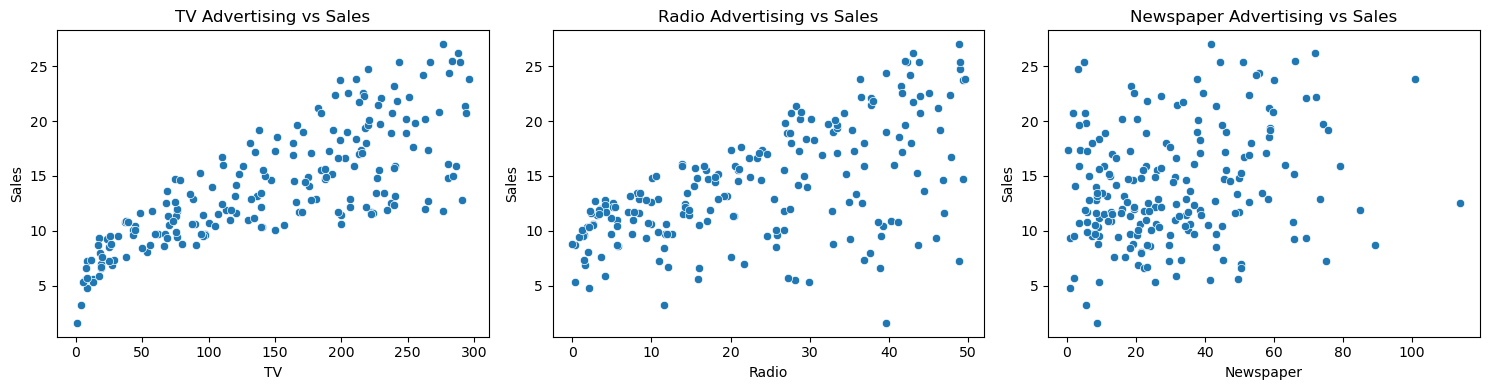

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Relationship between advertising and sales
plt.figure(figsize=(15, 4))

# TV vs Sales
plt.subplot(1, 3, 1)
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('TV Advertising vs Sales')

# Radio vs Sales
plt.subplot(1, 3, 2)
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title('Radio Advertising vs Sales')

# Newspaper vs Sales
plt.subplot(1, 3, 3)
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.title('Newspaper Advertising vs Sales')

plt.tight_layout()
plt.show()

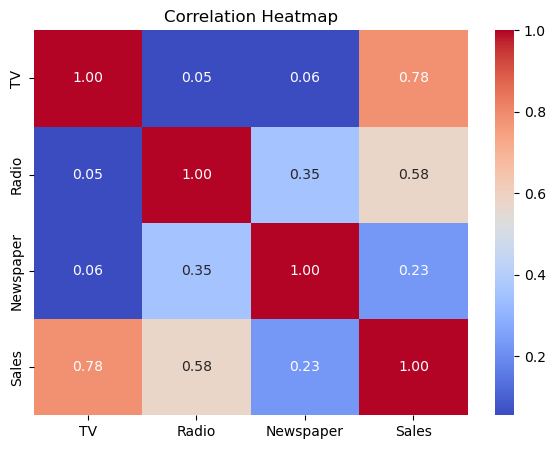

In [5]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [6]:
# Features
X = df[['TV', 'Radio', 'Newspaper']]

# Target
y = df['Sales']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [8]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [9]:
# Model coefficients
print("Intercept:", model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: 2.979067338122629

Coefficients:
TV : 0.044729517468716326
Radio : 0.18919505423437655
Newspaper : 0.0027611143413671757


In [10]:
# Predict sales for test data
y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred[:10])

Predicted Sales:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [14]:
# Compare actual vs predicted
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print(comparison.head(10))

   Actual Sales  Predicted Sales
0          16.9        16.408024
1          22.4        20.889882
2          21.4        21.553843
3           7.3        10.608503
4          24.7        22.112373
5          12.6        13.105592
6          22.3        21.057192
7           8.4         7.461010
8          11.5        13.606346
9          14.9        15.155070


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Model Evaluation
-----------------
MAE  : 1.4607567168117606
MSE  : 3.1740973539761046
RMSE : 1.7815996615334502
R²   : 0.899438024100912


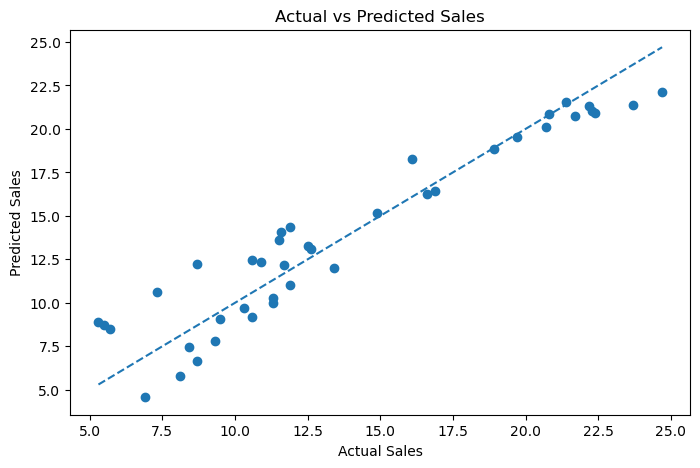

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

In [17]:
# Display model coefficients

coefficients = pd.DataFrame({
    'Advertising Channel': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

  Advertising Channel  Coefficient
0                  TV     0.044730
1               Radio     0.189195
2           Newspaper     0.002761


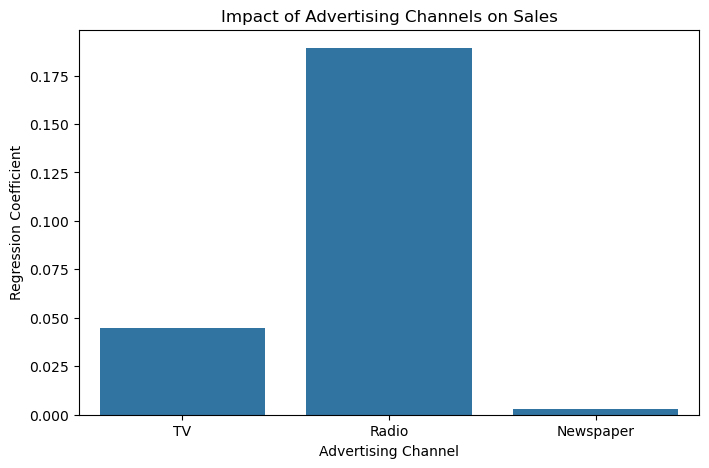

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Advertising Channel',
    y='Coefficient',
    data=coefficients
)

plt.title('Impact of Advertising Channels on Sales')
plt.xlabel('Advertising Channel')
plt.ylabel('Regression Coefficient')

plt.show()

In [19]:
# New advertising budget
new_advertising = pd.DataFrame({
    'TV': [200],
    'Radio': [30],
    'Newspaper': [40]
})

# Predict sales
predicted_sales = model.predict(new_advertising)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 17.711267032551877


In [20]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

Intercept: 2.979067338122629
TV: 0.0447
Radio: 0.1892
Newspaper: 0.0028


In [42]:
# Sales Prediction with User Input

print("======================================")
print("       SALES PREDICTION SYSTEM")
print("======================================")
print("Enter advertising expenditure values.")
print("Allowed range: 0 to 300")
print()

try:
    tv = float(input("Enter TV advertising budget (0-300): "))
    radio = float(input("Enter Radio advertising budget (0-300): "))
    newspaper = float(input("Enter Newspaper advertising budget (0-300): "))

    errors = []

    # Validate inputs
    if not (0 <= tv <= 300):
        errors.append("TV advertising budget must be between 0 and 300.")

    if not (0 <= radio <= 300):
        errors.append("Radio advertising budget must be between 0 and 300.")

    if not (0 <= newspaper <= 300):
        errors.append("Newspaper advertising budget must be between 0 and 300.")

    # Display all errors
    if errors:
        print("\n===== INPUT ERRORS =====")
        for error in errors:
            print("Error:", error)

    else:
        # Create input DataFrame
        new_data = pd.DataFrame({
            "TV": [tv],
            "Radio": [radio],
            "Newspaper": [newspaper]
        })

        # Predict sales
        prediction = model.predict(new_data)

        print("\n======================================")
        print("          PREDICTION RESULT")
        print("======================================")
        print(f"TV Advertising        : {tv:.2f}")
        print(f"Radio Advertising     : {radio:.2f}")
        print(f"Newspaper Advertising : {newspaper:.2f}")
        print("--------------------------------------")
        print(f"Predicted Sales       : {prediction[0]:.2f}")
        print("======================================")

except ValueError:
    print("\nError: Please enter numeric values only.")

       SALES PREDICTION SYSTEM
Enter advertising expenditure values.
Allowed range: 0 to 300



Enter TV advertising budget (0-300):  260
Enter Radio advertising budget (0-300):  159
Enter Newspaper advertising budget (0-300):  5



          PREDICTION RESULT
TV Advertising        : 260.00
Radio Advertising     : 159.00
Newspaper Advertising : 5.00
--------------------------------------
Predicted Sales       : 44.70
